# Pembagian Data Training / Validation / Testing

Membagi data dari `DATA FIX (Sudah Augmentasi).xlsx` (3200 baris) menjadi:
- **Training** : 80% (~2560 baris)
- **Validation** : 10% (~320 baris)
- **Testing** : 10% (~320 baris)

### Strategi pembagian (penting!)

1. **Group-aware split** — 4 versi dari 1 sampel sumber (Original + SNR 10/20/30 dB) **harus tetap di split yang sama** untuk menghindari *data leakage*. Misalnya, kalau Original sampel ke-5 di train, maka SNR_10dB / SNR_20dB / SNR_30dB sampel ke-5 juga harus di train.
2. **Stratified by Kode Sampel** — pembagian dilakukan agar tiap split memiliki proporsi 15 kelas multilabel yang seimbang.
3. **Random seed = 42** untuk reproducibility.

### Output

- `DATA SPLIT.xlsx` — file Excel dengan sheet terpisah per split
- `DATA SPLIT.npz` — numpy compressed file untuk loading cepat oleh model AI (jauh lebih cepat dari Excel)

## 1. Import Library & Konfigurasi

In [ ]:
import numpy as np
import pandas as pd
import openpyxl
import xlsxwriter
from sklearn.model_selection import train_test_split
import time, os

SEED         = 42
TRAIN_RATIO  = 0.80
VAL_RATIO    = 0.10
TEST_RATIO   = 0.10
N_CHANNELS   = 1024
ISOTOP_NAMES = ['Co-60', 'Cs-137', 'Ra-226', 'Eu-152']

BASE_DIR    = r"C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)"
INPUT_FILE  = os.path.join(BASE_DIR, "DATA FIX (Sudah Augmentasi).xlsx")
OUTPUT_XLSX = os.path.join(BASE_DIR, "DATA SPLIT.xlsx")
OUTPUT_NPZ  = os.path.join(BASE_DIR, "DATA SPLIT.npz")

np.random.seed(SEED)
print(f"Random seed       : {SEED}")
print(f"Split ratio       : Train {TRAIN_RATIO*100:.0f}%  |  Val {VAL_RATIO*100:.0f}%  |  Test {TEST_RATIO*100:.0f}%")

Random seed       : 42
Split ratio       : Train 80%  |  Val 10%  |  Test 10%


## 2. Baca Data dari File Excel

In [2]:
print("Membaca file augmented ...")
t0 = time.time()
wb = openpyxl.load_workbook(INPUT_FILE, read_only=True, data_only=True)

# --- Klasifikasi Multilabel: Kode Sampel -> 4 isotop binary ---
klas_rows = list(wb['Klasifikasi Multilabel'].iter_rows(values_only=True))
multilabel_map = {int(r[0]): [int(r[5]), int(r[6]), int(r[7]), int(r[8])]
                  for r in klas_rows[2:] if r[0] is not None}
print(f"  Klasifikasi : {len(multilabel_map)} kelas multilabel")

# --- Grafik ---
grafik_rows = list(wb['Grafik'].iter_rows(values_only=True))[1:]   # skip header
print(f"  Grafik      : {len(grafik_rows)} baris ({time.time()-t0:.1f}s)")

# --- Aktivitas Normalisasi ---
akt_rows = list(wb['Aktivitas Normalisasi'].iter_rows(values_only=True))[2:]   # skip 2 header rows
print(f"  Aktivitas N : {len(akt_rows)} baris ({time.time()-t0:.1f}s)")

wb.close()

# --- Konversi ke arrays ---
N = len(grafik_rows)
kode   = np.array([int(r[1]) for r in grafik_rows], dtype=np.int32)
jenis  = np.array([r[2]      for r in grafik_rows])
X      = np.array([[0.0 if v is None else float(v) for v in r[3:3+N_CHANNELS]] for r in grafik_rows],
                  dtype=np.float32)
y_reg  = np.array([[0.0 if v is None else float(v) for v in r[3:7]] for r in akt_rows],
                  dtype=np.float32)
y_cls  = np.array([multilabel_map[int(k)] for k in kode], dtype=np.float32)

print(f"\nShape:")
print(f"  X     (spektrum)         : {X.shape}")
print(f"  y_cls (multilabel)       : {y_cls.shape}")
print(f"  y_reg (aktivitas norm.)  : {y_reg.shape}")
print(f"  kode, jenis              : {kode.shape}, {jenis.shape}")
print(f"\nVerifikasi alignment Grafik vs Aktivitas:")
akt_kode = np.array([int(r[1]) for r in akt_rows], dtype=np.int32)
akt_jenis = np.array([r[2] for r in akt_rows])
mismatch = ((kode != akt_kode) | (jenis != akt_jenis)).sum()
print(f"  Mismatch: {mismatch} (0 = sempurna)")

Membaca file augmented ...
  Klasifikasi : 15 kelas multilabel
  Grafik      : 3200 baris (19.7s)
  Aktivitas N : 3200 baris (19.8s)

Shape:
  X     (spektrum)         : (3200, 1024)
  y_cls (multilabel)       : (3200, 4)
  y_reg (aktivitas norm.)  : (3200, 4)
  kode, jenis              : (3200,), (3200,)

Verifikasi alignment Grafik vs Aktivitas:
  Mismatch: 0 (0 = sempurna)


## 3. Identifikasi Source Sample

Tiap *source sample* memiliki 4 versi: Original, SNR_10dB, SNR_20dB, SNR_30dB. Untuk menghindari data leakage, kita harus menjaga 4 versi tetap dalam split yang sama.

Karena augmentasi dilakukan secara stable (urutan source dijaga dalam tiap Jenis), source ke-`i` dalam (`Kode K`, `Original`) berkorespondensi dengan source ke-`i` dalam (`Kode K`, `SNR_10dB`), dst.

Kita assign **source_id** unik untuk tiap (Kode, posisi-dalam-Jenis).

In [3]:
# Assign source_id: posisi-dalam-(Kode, Jenis) menjadi index source dalam Kode
source_idx_in_kode = np.zeros(N, dtype=np.int32)
counters = {}
for i in range(N):
    key = (int(kode[i]), str(jenis[i]))
    counters[key] = counters.get(key, -1) + 1
    source_idx_in_kode[i] = counters[key]

# source_id unik = Kode * 1000 + index_dalam_Kode
source_id = kode.astype(np.int64) * 1000 + source_idx_in_kode.astype(np.int64)

# Daftar source unik dan Kode-nya (untuk stratifikasi)
_, first_indices = np.unique(source_id, return_index=True)
first_indices.sort()
unique_sources = source_id[first_indices]
source_kode    = kode[first_indices]

print(f"Total source samples unik: {len(unique_sources)}")   # harus 800
from collections import Counter
cnt = Counter(source_kode.tolist())
print(f"\nDistribusi source per Kode Sampel:")
for k in sorted(cnt.keys()):
    print(f"  Kode {k:>2}: {cnt[k]} source samples")

Total source samples unik: 800

Distribusi source per Kode Sampel:
  Kode  1: 55 source samples
  Kode  2: 55 source samples
  Kode  3: 55 source samples
  Kode  4: 55 source samples
  Kode  5: 55 source samples
  Kode  6: 55 source samples
  Kode  7: 55 source samples
  Kode  8: 55 source samples
  Kode  9: 55 source samples
  Kode 10: 55 source samples
  Kode 11: 50 source samples
  Kode 12: 50 source samples
  Kode 13: 50 source samples
  Kode 14: 50 source samples
  Kode 15: 50 source samples


## 4. Stratified Group-Aware Split (80 / 10 / 10)

Split dilakukan pada level **source** (800 sampel), bukan level row (3200 baris). Stratified by `Kode Sampel`.

In [4]:
# Step 1: 80% train vs 20% (val+test)
src_train, src_temp, kode_tr, kode_tm = train_test_split(
    unique_sources, source_kode,
    test_size = VAL_RATIO + TEST_RATIO,
    stratify  = source_kode,
    random_state = SEED
)
# Step 2: dari 20%, bagi 50/50 -> 10% val, 10% test
src_val, src_test, _, _ = train_test_split(
    src_temp, kode_tm,
    test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify  = kode_tm,
    random_state = SEED
)

# Build assignment: source_id -> 'train' / 'val' / 'test'
set_train, set_val, set_test = set(src_train.tolist()), set(src_val.tolist()), set(src_test.tolist())
split = np.array(['?']*N, dtype=object)
for i in range(N):
    sid = int(source_id[i])
    if   sid in set_train: split[i] = 'train'
    elif sid in set_val:   split[i] = 'val'
    elif sid in set_test:  split[i] = 'test'

print("=== Pembagian Source Sample ===")
print(f"  Train : {len(src_train):>3d} sources ({len(src_train)/800*100:.1f}%)")
print(f"  Val   : {len(src_val):>3d} sources ({len(src_val)/800*100:.1f}%)")
print(f"  Test  : {len(src_test):>3d} sources ({len(src_test)/800*100:.1f}%)")

print("\n=== Pembagian Baris (setelah augmentasi) ===")
for s in ['train', 'val', 'test']:
    print(f"  {s:5s} : {(split == s).sum():>4d} baris ({(split == s).sum()/N*100:.1f}%)")

print("\n=== Stratifikasi per Kode Sampel (jumlah source) ===")
print(f"{'Kode':<6}{'Train':<8}{'Val':<6}{'Test':<6}{'Total':<6}")
for k in sorted(np.unique(source_kode).tolist()):
    t = ((kode_tr == k).sum() if k in kode_tr else 0)
    # Recompute correctly from unique sources
    n_tr = sum(1 for s, kk in zip(unique_sources, source_kode) if kk == k and int(s) in set_train)
    n_va = sum(1 for s, kk in zip(unique_sources, source_kode) if kk == k and int(s) in set_val)
    n_te = sum(1 for s, kk in zip(unique_sources, source_kode) if kk == k and int(s) in set_test)
    print(f"{k:<6}{n_tr:<8}{n_va:<6}{n_te:<6}{n_tr+n_va+n_te:<6}")

# Verifikasi: tiap source punya tepat 4 versi
from collections import Counter
split_per_source = {}
for i in range(N):
    sid = int(source_id[i])
    split_per_source.setdefault(sid, []).append(split[i])
consistent = all(len(set(v)) == 1 and len(v) == 4 for v in split_per_source.values())
print(f"\nVerifikasi: setiap source punya 4 versi di split yang sama? {consistent}")

=== Pembagian Source Sample ===
  Train : 640 sources (80.0%)
  Val   :  80 sources (10.0%)
  Test  :  80 sources (10.0%)

=== Pembagian Baris (setelah augmentasi) ===
  train : 2560 baris (80.0%)
  val   :  320 baris (10.0%)
  test  :  320 baris (10.0%)

=== Stratifikasi per Kode Sampel (jumlah source) ===
Kode  Train   Val   Test  Total 
1     44      6     5     55    
2     44      6     5     55    
3     44      5     6     55    
4     44      5     6     55    
5     44      5     6     55    
6     44      6     5     55    
7     44      5     6     55    
8     44      6     5     55    
9     44      6     5     55    
10    44      5     6     55    
11    40      5     5     50    
12    40      5     5     50    
13    40      5     5     50    
14    40      5     5     50    
15    40      5     5     50    

Verifikasi: setiap source punya 4 versi di split yang sama? True


## 5. Simpan ke `DATA SPLIT.npz` (untuk Loading Cepat ke Model AI)

In [5]:
mask_train = split == 'train'
mask_val   = split == 'val'
mask_test  = split == 'test'

np.savez_compressed(
    OUTPUT_NPZ,
    # Train
    X_train     = X[mask_train],
    y_cls_train = y_cls[mask_train],
    y_reg_train = y_reg[mask_train],
    kode_train  = kode[mask_train],
    jenis_train = jenis[mask_train].astype('U16'),
    # Val
    X_val       = X[mask_val],
    y_cls_val   = y_cls[mask_val],
    y_reg_val   = y_reg[mask_val],
    kode_val    = kode[mask_val],
    jenis_val   = jenis[mask_val].astype('U16'),
    # Test
    X_test      = X[mask_test],
    y_cls_test  = y_cls[mask_test],
    y_reg_test  = y_reg[mask_test],
    kode_test   = kode[mask_test],
    jenis_test  = jenis[mask_test].astype('U16'),
    # Meta
    isotop_names = np.array(ISOTOP_NAMES, dtype='U10')
)
size_mb = os.path.getsize(OUTPUT_NPZ) / 1024 / 1024
print(f"Disimpan : {OUTPUT_NPZ}")
print(f"Ukuran   : {size_mb:.1f} MB")

Disimpan : C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\DATA SPLIT.npz
Ukuran   : 10.0 MB


## 6. Simpan ke `DATA SPLIT.xlsx`

Format sheet mengikuti `Tabel Pre-processing (contoh).xlsx`:

- `Summary` — info ringkas pembagian
- `X_train`, `X_val`, `X_test` — spektrum (No, Ch_0..Ch_1023)
- `y_train klasifikasi`, `y_val klasifikasi`, `y_test klasifikasi` — label biner per isotop + Komposisi Radioisotop
- `y_train regresi`, `y_val regresi`, `y_test regresi` — aktivitas hasil normalisasi + Komposisi Radioisotop

Header sheet `y_*`: dua baris dengan merged cell — `No` (kolom A), `Label Sampel` / `Aktivitas Hasil Normalisasi` (4 kolom isotop), dan `Komposisi Radioisotop` (4 kolom `Isotop 1..4`).

In [6]:
print("Menulis DATA SPLIT.xlsx ...")
t1 = time.time()
wb_out = xlsxwriter.Workbook(OUTPUT_XLSX, {'constant_memory': True})
fmt_hdr = wb_out.add_format({'bold': True, 'align': 'center', 'valign': 'vcenter'})

def write_split(name, mask):
    """Tulis 3 sheet per split: X_{name}, y_{name} klasifikasi, y_{name} regresi"""
    idxs = np.where(mask)[0]

    # --- X_{name}: No, Ch_0..Ch_1023 ---
    ws_x = wb_out.add_worksheet(f'X_{name}')
    ws_x.write(0, 0, 'No', fmt_hdr)
    for c in range(N_CHANNELS):
        ws_x.write(0, 1 + c, f'Ch_{c}', fmt_hdr)
    for r, idx in enumerate(idxs):
        ws_x.write(r + 1, 0, r)
        ws_x.write_row(r + 1, 1, X[idx].tolist())

    # --- y_{name} klasifikasi: No | Label Sampel (4 isotop) | Komposisi Radioisotop (Isotop 1..4) ---
    ws_c = wb_out.add_worksheet(f'y_{name} klasifikasi')
    ws_c.merge_range(0, 0, 1, 0, 'No', fmt_hdr)
    ws_c.merge_range(0, 1, 0, 4, 'Label Sampel', fmt_hdr)
    ws_c.merge_range(0, 5, 0, 8, 'Komposisi Radioisotop', fmt_hdr)
    for c, iso in enumerate(ISOTOP_NAMES):
        ws_c.write(1, 1 + c, iso, fmt_hdr)
    for c in range(4):
        ws_c.write(1, 5 + c, f'Isotop {c + 1}', fmt_hdr)
    for r, idx in enumerate(idxs):
        row = r + 2
        ws_c.write(row, 0, r)
        for c, v in enumerate(y_cls[idx]):
            ws_c.write(row, 1 + c, int(v))
        present = [ISOTOP_NAMES[i] for i, v in enumerate(y_cls[idx]) if int(v) == 1]
        for c, nm in enumerate(present):
            ws_c.write(row, 5 + c, nm)

    # --- y_{name} regresi: No | Aktivitas Hasil Normalisasi (4 isotop) | Komposisi Radioisotop ---
    ws_r = wb_out.add_worksheet(f'y_{name} regresi')
    ws_r.merge_range(0, 0, 1, 0, 'No', fmt_hdr)
    ws_r.merge_range(0, 1, 0, 4, 'Aktivitas Hasil Normalisasi', fmt_hdr)
    ws_r.merge_range(0, 5, 0, 8, 'Komposisi Radioisotop', fmt_hdr)
    for c, iso in enumerate(ISOTOP_NAMES):
        ws_r.write(1, 1 + c, iso, fmt_hdr)
    for c in range(4):
        ws_r.write(1, 5 + c, f'Isotop {c + 1}', fmt_hdr)
    for r, idx in enumerate(idxs):
        row = r + 2
        ws_r.write(row, 0, r)
        for c, v in enumerate(y_reg[idx]):
            ws_r.write(row, 1 + c, float(v))
        present = [ISOTOP_NAMES[i] for i, v in enumerate(y_cls[idx]) if int(v) == 1]
        for c, nm in enumerate(present):
            ws_r.write(row, 5 + c, nm)

    print(f"  {name:5s}: {len(idxs)} rows -> 3 sheets ({time.time()-t1:.1f}s)")

# --- Summary sheet (ditulis pertama agar tab paling kiri) ---
ws_s = wb_out.add_worksheet('Summary')
summary = [
    ['Split', 'Source Samples', 'Rows (4x Augmented)', 'Persen (Source)'],
    ['Train', len(src_train), int(mask_train.sum()), f'{len(src_train)/800*100:.1f}%'],
    ['Val',   len(src_val),   int(mask_val.sum()),   f'{len(src_val)/800*100:.1f}%'],
    ['Test',  len(src_test),  int(mask_test.sum()),  f'{len(src_test)/800*100:.1f}%'],
    ['Total', 800, N, '100.0%'],
    [],
    ['Random Seed', SEED],
    ['Stratified by', 'Kode Sampel (15 kelas multilabel)'],
    ['Group-aware?', 'Ya - 4 versi (Original + SNR 10/20/30 dB) selalu di split sama'],
]
for r, row in enumerate(summary):
    for c, v in enumerate(row):
        ws_s.write(r, c, v, fmt_hdr if r == 0 else None)

write_split('train', mask_train)
write_split('val',   mask_val)
write_split('test',  mask_test)

wb_out.close()

size_mb = os.path.getsize(OUTPUT_XLSX) / 1024 / 1024
print(f"\nFile tersimpan : {OUTPUT_XLSX}")
print(f"Ukuran file    : {size_mb:.1f} MB")
print(f"Waktu          : {time.time()-t1:.1f}s")

Menulis DATA SPLIT.xlsx ...
  train: 2560 rows -> 3 sheets (7.9s)
  val  : 320 rows -> 3 sheets (8.9s)
  test : 320 rows -> 3 sheets (9.8s)

File tersimpan : C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\DATA SPLIT.xlsx
Ukuran file    : 35.4 MB
Waktu          : 14.4s


## 7. Visualisasi Distribusi Split

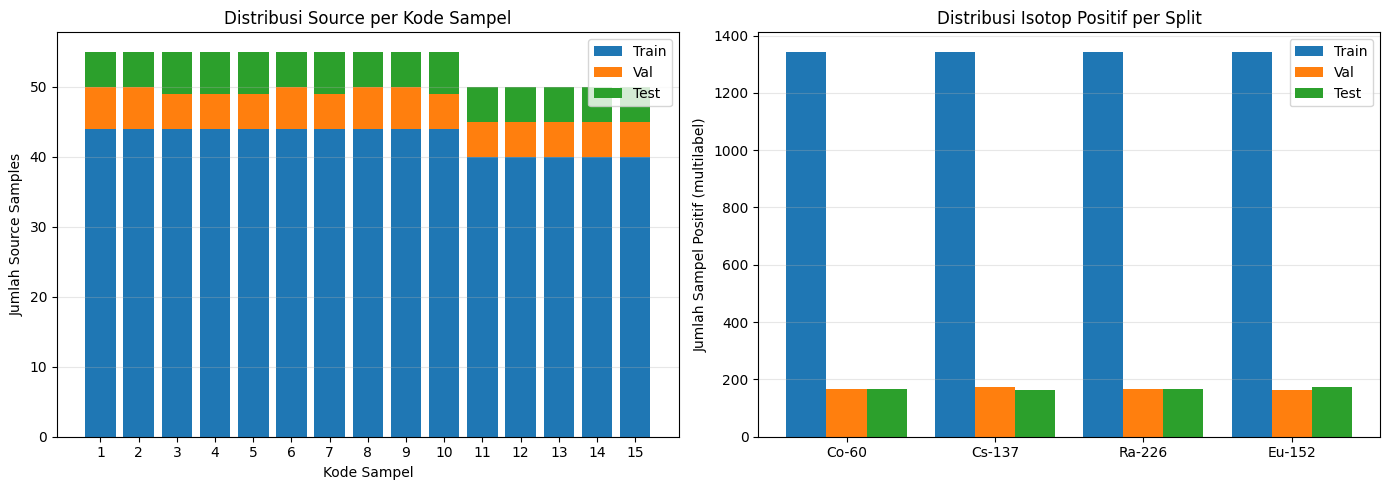

Plot disimpan: split_distribution.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Distribusi source per Kode per split
kodes = sorted(np.unique(source_kode).tolist())
train_counts, val_counts, test_counts = [], [], []
for k in kodes:
    n_tr = sum(1 for s, kk in zip(unique_sources, source_kode) if kk == k and int(s) in set_train)
    n_va = sum(1 for s, kk in zip(unique_sources, source_kode) if kk == k and int(s) in set_val)
    n_te = sum(1 for s, kk in zip(unique_sources, source_kode) if kk == k and int(s) in set_test)
    train_counts.append(n_tr); val_counts.append(n_va); test_counts.append(n_te)

x = np.arange(len(kodes))
axes[0].bar(x, train_counts, label='Train', color='tab:blue')
axes[0].bar(x, val_counts,   bottom=train_counts, label='Val', color='tab:orange')
axes[0].bar(x, test_counts,  bottom=np.array(train_counts)+np.array(val_counts), label='Test', color='tab:green')
axes[0].set_xticks(x); axes[0].set_xticklabels(kodes)
axes[0].set_xlabel('Kode Sampel'); axes[0].set_ylabel('Jumlah Source Samples')
axes[0].set_title('Distribusi Source per Kode Sampel')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

# (b) Distribusi per isotop (multilabel)
iso_counts = {'Train': [0]*4, 'Val': [0]*4, 'Test': [0]*4}
for s, mask, name in [('Train', mask_train, 'Train'), ('Val', mask_val, 'Val'), ('Test', mask_test, 'Test')]:
    iso_counts[name] = y_cls[mask].sum(axis=0).astype(int).tolist()

x = np.arange(len(ISOTOP_NAMES))
w = 0.27
axes[1].bar(x - w, iso_counts['Train'], w, label='Train', color='tab:blue')
axes[1].bar(x,     iso_counts['Val'],   w, label='Val',   color='tab:orange')
axes[1].bar(x + w, iso_counts['Test'],  w, label='Test',  color='tab:green')
axes[1].set_xticks(x); axes[1].set_xticklabels(ISOTOP_NAMES)
axes[1].set_ylabel('Jumlah Sampel Positif (multilabel)')
axes[1].set_title('Distribusi Isotop Positif per Split')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'split_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan: split_distribution.png')